In [1]:
!pip install tensorflow==2.12.0
!pip install keras

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.9/585.9 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 21.9 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.0
    Uninst

In [2]:
!pip install pandas pillow

In [3]:
!pip install pandas
!pip install opencv-python

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

# Set constants
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
AUTOTUNE = tf.data.AUTOTUNE
PATCH_SIZE = 16
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
EMBED_DIM = 64
NUM_HEADS = 4
FF_DIM = 128
NUM_LAYERS = 6

# Path to dataset
dataset_path = '/kaggle/input/jute-leaf-disease-dataset'

# Subfolders for split data
train_path = os.path.join(dataset_path, 'train')
val_path = os.path.join(dataset_path, 'val')
test_path = os.path.join(dataset_path, 'test')

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Class info
class_names = train_ds.class_names
num_classes = len(class_names)
print("Class Names:", class_names)

# Rescaling and augmentation
rescale_layer = layers.Rescaling(1./255)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Preprocessing function
def preprocess(ds, augment=False):
    ds = ds.map(lambda x, y: (rescale_layer(x), y), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(buffer_size=AUTOTUNE)

train_ds = preprocess(train_ds, augment=True)
val_ds = preprocess(val_ds)
test_ds = preprocess(test_ds)

# Compute class weights
all_labels = []
for _, label in train_ds.unbatch():
    all_labels.append(label.numpy())

labels = np.array(all_labels)
class_weights_raw = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = {i: w for i, w in enumerate(class_weights_raw)}
print("Class Weights:", class_weights)

# Patch extraction layer
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )
        patch_dims = patches.shape[-1]
        return tf.reshape(patches, [batch_size, -1, patch_dims])

# Patch encoder layer
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patches):
        positions = tf.range(start=0, limit=tf.shape(patches)[1], delta=1)
        encoded = self.projection(patches) + self.position_embedding(positions)
        return encoded

# MLP block
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

# Transformer block
def transformer_block(x, num_heads, projection_dim, transformer_units, dropout_rate):
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim, dropout=dropout_rate
    )(x1, x1)
    x2 = layers.Add()([attention_output, x])
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = mlp(x3, hidden_units=[transformer_units, projection_dim], dropout_rate=dropout_rate)
    return layers.Add()([x3, x2])

# Build ViT model
def build_vit_model(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), num_classes=num_classes):
    inputs = layers.Input(shape=input_shape)
    patches = Patches(PATCH_SIZE)(inputs)
    encoded_patches = PatchEncoder(NUM_PATCHES, EMBED_DIM)(patches)

    for _ in range(NUM_LAYERS):
        encoded_patches = transformer_block(encoded_patches, NUM_HEADS, EMBED_DIM, FF_DIM, 0.1)

    x = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.1)(x)
    x = mlp(x, hidden_units=[FF_DIM], dropout_rate=0.1)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs=inputs, outputs=outputs)






Found 35000 files belonging to 3 classes.
Found 900 files belonging to 3 classes.
Found 900 files belonging to 3 classes.
Class Names: ['Cescospora Leaf Spot', 'Golden Mosaic', 'Healthy Leaf']
Class Weights: {0: 0.9920634920634921, 1: 0.8785140562248996, 2: 1.1713520749665327}


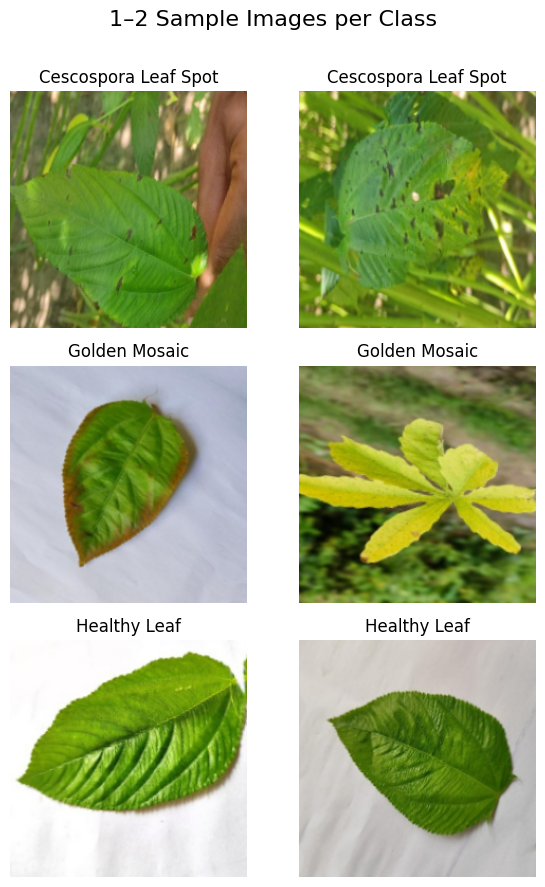

In [5]:
import matplotlib.pyplot as plt

# Build a dictionary to store 2 images per class
class_samples = {class_name: [] for class_name in class_names}

# Loop through unbatched dataset to collect samples
for image, label in train_ds.unbatch():
    class_name = class_names[label.numpy()]
    if len(class_samples[class_name]) < 2:
        class_samples[class_name].append(image)
    # Stop if we have 2 images for every class
    if all(len(imgs) == 2 for imgs in class_samples.values()):
        break

# Plot the collected samples
fig, axes = plt.subplots(len(class_names), 2, figsize=(6, 3 * len(class_names)))
fig.suptitle("1–2 Sample Images per Class", fontsize=16)

for i, class_name in enumerate(class_names):
    for j in range(2):
        ax = axes[i, j] if len(class_names) > 1 else axes[j]
        if j < len(class_samples[class_name]):
            img = class_samples[class_name][j].numpy()
            
            # If image is normalized to [0,1], convert back to [0,255]
            if img.max() <= 1.0:
                img = (img * 255).astype("uint8")
            else:
                img = img.astype("uint8")
            
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"{class_name}")
        else:
            ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [6]:
def visualize_one_patch_per_class(dataset, class_names, patch_size):
    collected = {}

    # Unbatch and loop through the dataset to get one image per class
    dataset = dataset.unbatch()

    for img, label in dataset:
        label = label.numpy()
        class_name = class_names[label]
        if class_name not in collected:
            collected[class_name] = img
        if len(collected) == len(class_names):
            break

    # Loop over collected images
    for class_name, image in collected.items():
        print(f"Class: {class_name}")

        # Convert image back from [0,1] if necessary
        img_np = image.numpy()
        if img_np.max() <= 1.0:
            img_disp = (img_np * 255).astype("uint8")
        else:
            img_disp = img_np.astype("uint8")

        # Show the original image
        plt.figure(figsize=(3, 3))
        plt.imshow(img_disp)
        plt.axis("off")
        plt.title(f"Original: {class_name}")
        plt.show()

        # Create patches
        patches_layer = Patches(patch_size)
        normalized_img = tf.expand_dims(image, axis=0)
        patches = patches_layer(normalized_img)
        print(f"{class_name} - Patches shape: {patches.shape}")

        # Display up to 16 patches
        plt.figure(figsize=(4, 4))
        for i in range(min(16, patches.shape[1])):
            patch = patches[0, i]
            patch_dim = int(tf.math.sqrt(tf.cast(patch.shape[0] // 3, tf.float32)))
            patch_img = tf.reshape(patch, (patch_dim, patch_dim, 3))
            patch_img = tf.clip_by_value(patch_img, 0.0, 1.0).numpy()
            plt.subplot(4, 4, i + 1)
            plt.imshow(patch_img)
            plt.axis("off")

        plt.suptitle(f"Patches: {class_name}")
        plt.tight_layout()
        plt.show()


Class: Healthy Leaf


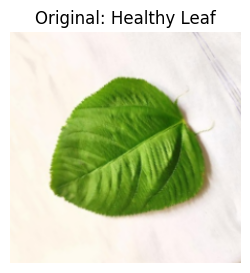

Healthy Leaf - Patches shape: (1, 196, 768)


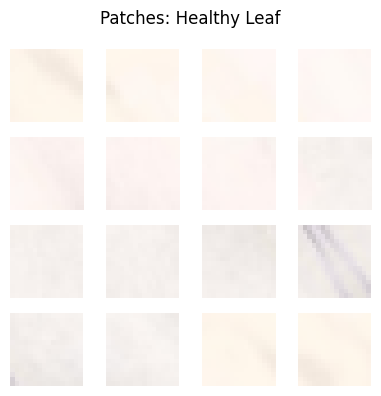

Class: Golden Mosaic


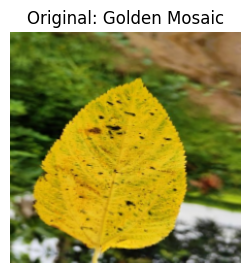

Golden Mosaic - Patches shape: (1, 196, 768)


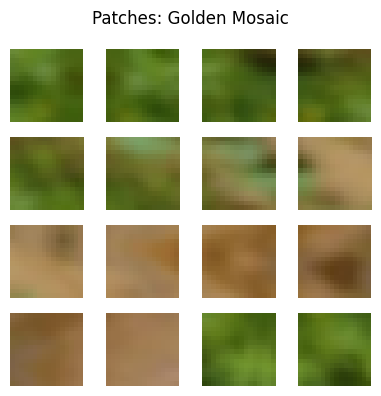

Class: Cescospora Leaf Spot


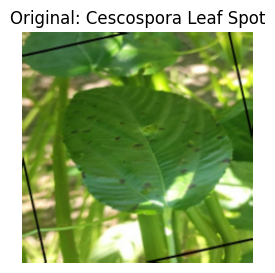

Cescospora Leaf Spot - Patches shape: (1, 196, 768)


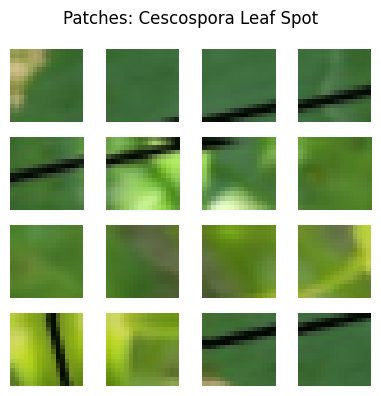

In [7]:
visualize_one_patch_per_class(train_ds, class_names, patch_size=PATCH_SIZE)

In [8]:

# Instantiate and compile the model
model = build_vit_model()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 patches_3 (Patches)            (None, None, 768)    0           ['input_1[0][0]']                
                                                                                                  
 patch_encoder (PatchEncoder)   (None, None, 64)     61760       ['patches_3[0][0]']              
                                                                                                  
 layer_normalization (LayerNorm  (None, None, 64)    128         ['patch_encoder[0][0]']      

In [9]:
# Train the model
# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

Epoch 1/10
1094/1094 [==============================] - 1444s 1s/step - loss: 0.5770 - accuracy: 0.7289 - val_loss: 0.4752 - val_accuracy: 0.7911
Epoch 2/10
1094/1094 [==============================] - 1411s 1s/step - loss: 0.4315 - accuracy: 0.8115 - val_loss: 0.3874 - val_accuracy: 0.8433
Epoch 3/10
1094/1094 [==============================] - 1417s 1s/step - loss: 0.3880 - accuracy: 0.8307 - val_loss: 0.3467 - val_accuracy: 0.8522
Epoch 4/10
1094/1094 [==============================] - 1403s 1s/step - loss: 0.3644 - accuracy: 0.8401 - val_loss: 0.3706 - val_accuracy: 0.8522
Epoch 5/10
1094/1094 [==============================] - 1395s 1s/step - loss: 0.3184 - accuracy: 0.8624 - val_loss: 0.2984 - val_accuracy: 0.8767
Epoch 6/10
1094/1094 [==============================] - 1388s 1s/step - loss: 0.2960 - accuracy: 0.8740 - val_loss: 0.2453 - val_accuracy: 0.9056
Epoch 7/10
1094/1094 [==============================] - 1406s 1s/step - loss: 0.2609 - accuracy: 0.8908 - val_loss: 0.2000 -

In [10]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.2f}")

29/29 [==============================] - 11s 382ms/step - loss: 0.1475 - accuracy: 0.9467
Test Accuracy: 0.95


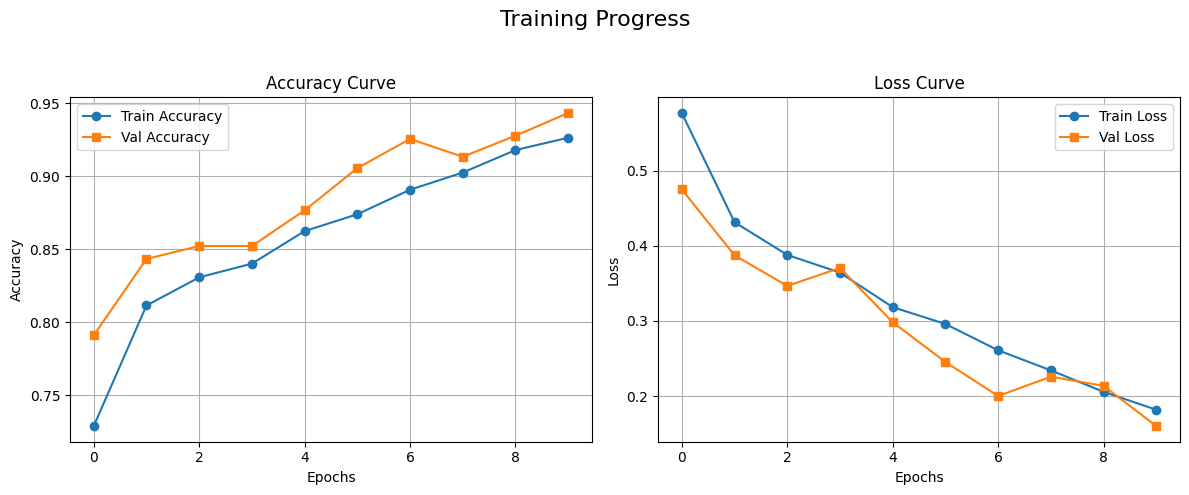

In [11]:
import matplotlib.pyplot as plt

# Create subplots for Accuracy and Loss
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot Accuracy
axs[0].plot(history.history["accuracy"], label="Train Accuracy", marker='o')
axs[0].plot(history.history["val_accuracy"], label="Val Accuracy", marker='s')
axs[0].set_title("Accuracy Curve")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Accuracy")
axs[0].legend()
axs[0].grid(True)

# Plot Loss
axs[1].plot(history.history["loss"], label="Train Loss", marker='o')
axs[1].plot(history.history["val_loss"], label="Val Loss", marker='s')
axs[1].set_title("Loss Curve")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Loss")
axs[1].legend()
axs[1].grid(True)

# Layout adjustments
plt.suptitle("Training Progress", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [12]:
# Collect true and predicted labels
true_labels = []
pred_labels = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    true_labels.extend(labels.numpy())
    pred_labels.extend(np.argmax(preds, axis=1))

# Convert to numpy arrays
true_labels = np.array(true_labels)
pred_labels = np.array(pred_labels)

📊 Classification Report:

                      precision    recall  f1-score   support

Cescospora Leaf Spot       0.97      0.88      0.92       300
       Golden Mosaic       0.91      0.97      0.94       300
        Healthy Leaf       0.96      0.98      0.97       300

            accuracy                           0.94       900
           macro avg       0.94      0.94      0.94       900
        weighted avg       0.94      0.94      0.94       900

✅ Overall Validation Accuracy: 0.9433


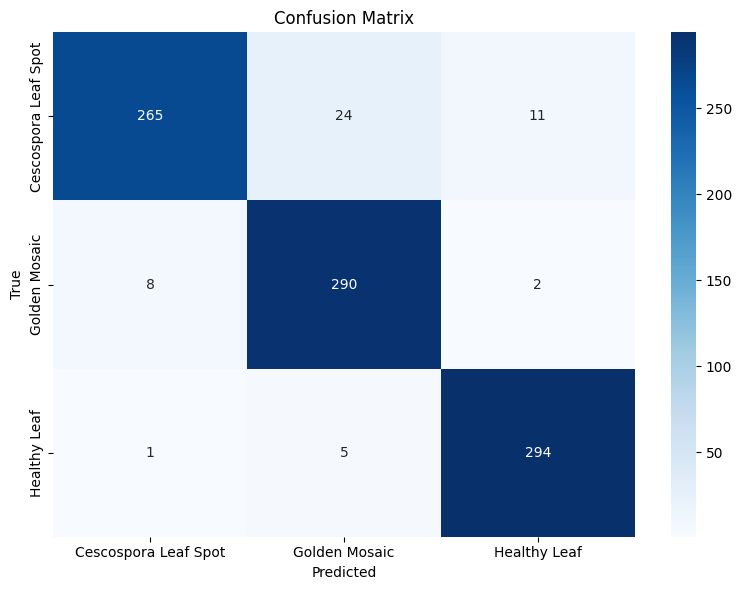

In [13]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Collect true and predicted labels
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Convert to arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print("📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"✅ Overall Validation Accuracy: {accuracy:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


<ipython-input-14-f2e0cccdeca0>:32: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


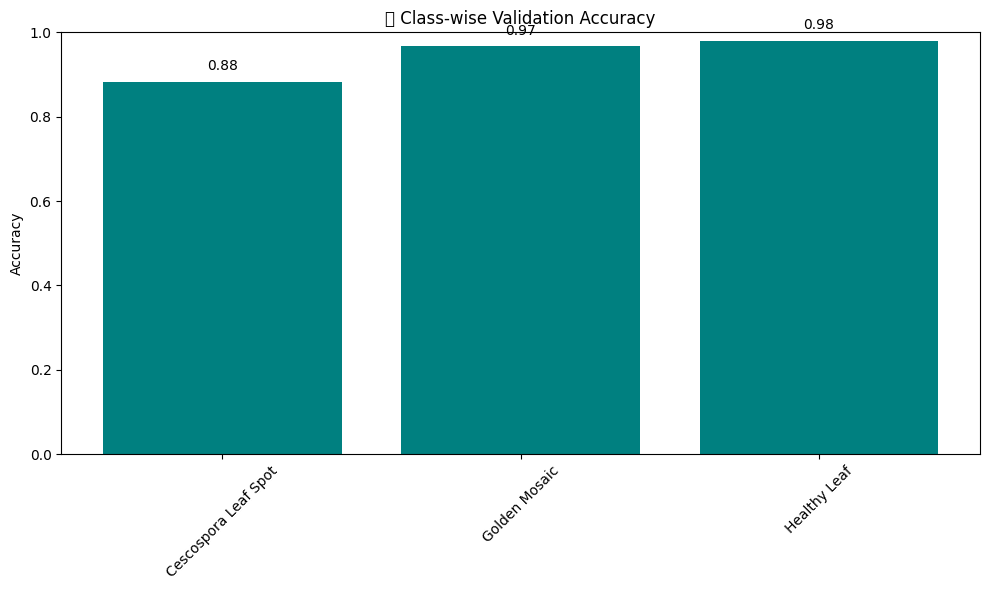

In [14]:
# Calculate class-wise counts
class_counts = {cls: 0 for cls in class_names}
correct_counts = {cls: 0 for cls in class_names}

# Loop through predictions
for true, pred in zip(true_labels, pred_labels):
    class_name = class_names[true]
    class_counts[class_name] += 1
    if true == pred:
        correct_counts[class_name] += 1

# Class-wise accuracy
classwise_acc = {
    cls: correct_counts[cls] / class_counts[cls] if class_counts[cls] > 0 else 0.0
    for cls in class_names
}

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(classwise_acc.keys(), classwise_acc.values(), color='teal')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("🔍 Class-wise Validation Accuracy")

# Add accuracy values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.02, f"{height:.2f}", 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [15]:
# Test with New Image

def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0)
    predictions = vit_model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(tf.nn.softmax(predictions))
    print(f"Predicted: {predicted_class} ({confidence:.2%})")